In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
relu = lambda x: np.maximum(0, x)

In [3]:
softmax = lambda z: (E := np.exp(z)) / np.sum(E, axis = 1, keepdims=True)

In [14]:
cross_entropy = lambda T, S: -np.sum(T * np.log(S + 1e-8)) / T.shape[0]

In [5]:
forward = lambda W2, Z: softmax(relu(Z) @ W2)

In [6]:
sigma = lambda X, W: X @ W

In [7]:
grad1 = lambda X, S, T, W2, Z: (X.T @ ((S - T) @ W2.T * (Z > 0))) / X.shape[0]
grad2 = lambda X, S, T, Z: relu(Z).T @ (S - T) / X.shape[0]

In [8]:
loaded_data = fetch_openml('mnist_784', version=1, as_frame=False)

In [9]:
X, y = loaded_data.data, loaded_data.target
X = X.astype(np.float32)
X /= 255.0

In [ ]:
np.random.seed(42)
num_epoch = 1000
W1 = np.random.rand(784, 64) * 0.01
W2 = np.random.rand(64, 10) * 0.01

T = np.eye(10)[y.astype(int)]
num_data = X.shape[0]
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, T_train = X[shuffle[:split]], T[shuffle[:split]]
X_test, T_test = X[shuffle[split:]], T[shuffle[split:]]
lr = 0.1
snapshot_delay = 100
test_labels = np.argmax(T_test, axis=1)
num_test = X_test.shape[0]

In [23]:
for epoch in range(num_epoch):
    # forward
    Z_train = sigma(X_train, W1)
    S_train = forward(W2, Z_train)

    if epoch % snapshot_delay == 0:
        Z_test = sigma(X_test, W1)
        S_test = forward(W2, Z_test)

        preds = np.argmax(S_test, axis=1)
        acc = np.sum(test_labels == preds)/num_test

        train_loss = cross_entropy(T_train, S_train)
        test_loss = cross_entropy(T_test, S_test)

        print(f"Epoch: {epoch} acc: {acc}")
        print("Train loss: ", train_loss)
        print("Test loss: ", test_loss)

    # backward
    W1 -= lr * grad1(X_train, S_train, T_train, W2, Z_train)
    W2 -= lr* grad2(X_train,S_train, T_train, Z_train)

Epoch: 0 acc: 0.09378571428571429
Train loss:  2.3031004471924117
Test loss:  2.3030776201598036
Epoch: 100 acc: 0.6717142857142857
Train loss:  1.3664953896783976
Test loss:  1.3649232152721265
Epoch: 200 acc: 0.8328571428571429
Train loss:  0.6150367478205696
Test loss:  0.6095547047745965
Epoch: 300 acc: 0.8738571428571429
Train loss:  0.4626768803538824
Test loss:  0.4568257600372182
Epoch: 400 acc: 0.8895714285714286
Train loss:  0.4017509969694146
Test loss:  0.3961306668453582
Epoch: 500 acc: 0.8993571428571429
Train loss:  0.36841421996500895
Test loss:  0.36370773644768517
Epoch: 600 acc: 0.9038571428571428
Train loss:  0.3467240775428007
Test loss:  0.3430784922290036
Epoch: 700 acc: 0.9072857142857143
Train loss:  0.3307891592266077
Test loss:  0.3281960305347485
Epoch: 800 acc: 0.9115
Train loss:  0.3181622647074934
Test loss:  0.3166135438083616
Epoch: 900 acc: 0.9146428571428571
Train loss:  0.3076394447692789
Test loss:  0.3070796553320293


In [24]:
print(f"final accuracy: {acc}")

final accuracy: 0.9146428571428571


In [25]:
X_test_pred = np.argmax(softmax(forward(W2, sigma(X_test, W1))), axis=1)

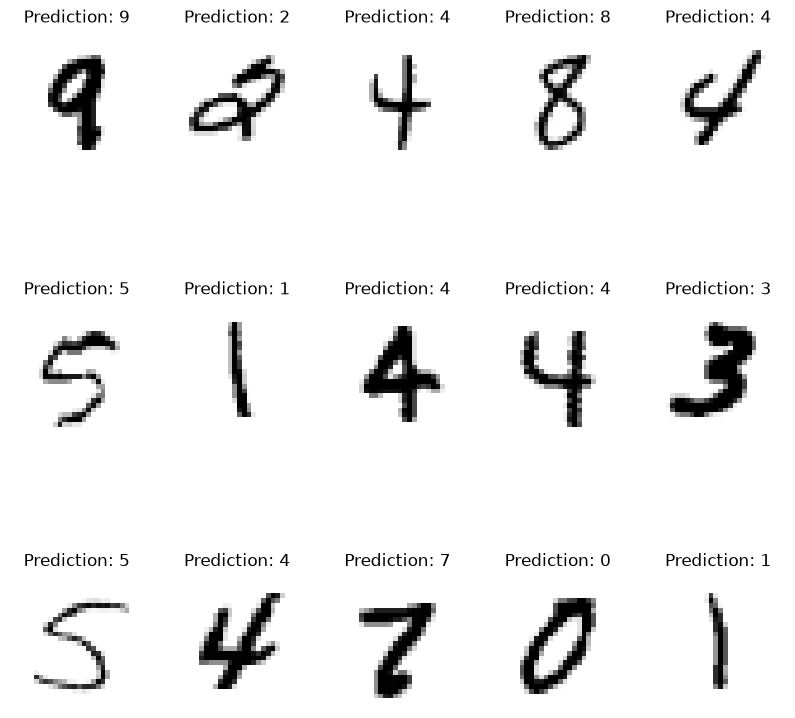

In [26]:
fig, ax = plt.subplots(3,5, figsize=[10, 10])
for i in range(15):
    ax[i//5, i%5].imshow(np.reshape(X_test[i], (28, 28)), cmap='binary')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Prediction: {X_test_pred[i]}")